In [46]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, MinMaxScaler, RobustScaler

Compute descriptive statistic for a real dataset; identify skewed distributions; apply Z-Score normalizaation; compute pearson and spearman correlations.


In [2]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Descriptive Statistics


In [3]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## Skewed Distribution


In [4]:
numeric_cols = df.select_dtypes(include='number')
numeric_cols.skew()

total_bill    1.133213
tip           1.465451
size          1.447882
dtype: float64

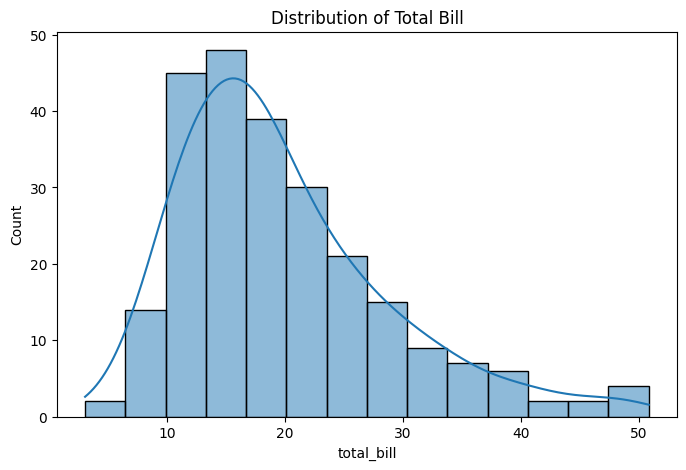

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(df['total_bill'], kde=True)

plt.title('Distribution of Total Bill')
plt.show()

## Z- Score


In [6]:
mean = numeric_cols.mean()
std = numeric_cols.std()

z_score = (numeric_cols - mean) / std

print(f'Z-Score :\n{z_score.head()}')

Z-Score :
   total_bill       tip      size
0   -0.314066 -1.436993 -0.598961
1   -1.061054 -0.967217  0.452453
2    0.137497  0.362610  0.452453
3    0.437416  0.225291 -0.598961
4    0.539635  0.442111  1.503867


## Pearson Correlations


Pearson Correlation:
             total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


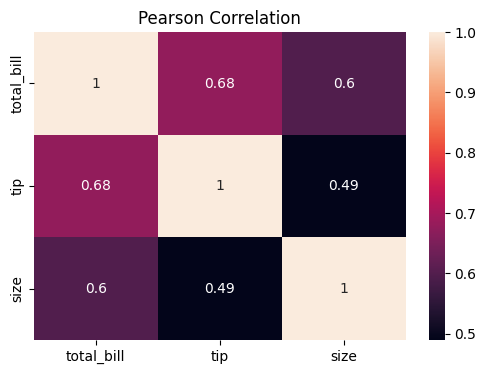

In [7]:
pearson_corr = numeric_cols.corr(method='pearson')
print("Pearson Correlation:\n", pearson_corr)

plt.figure(figsize=(6, 4))
sns.heatmap(pearson_corr, annot=True)
plt.title('Pearson Correlation')
plt.show()

## Spearman Correlation


Spearman Correlation:
             total_bill       tip      size
total_bill    1.000000  0.678968  0.604791
tip           0.678968  1.000000  0.468268
size          0.604791  0.468268  1.000000


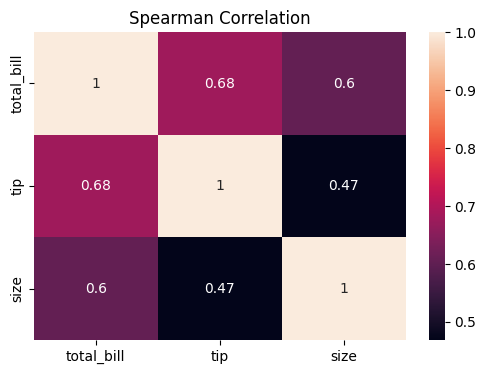

In [8]:
spearman_corr = numeric_cols.corr(method='spearman')
print("Spearman Correlation:\n", spearman_corr)

plt.figure(figsize=(6, 4))
sns.heatmap(spearman_corr, annot=True)
plt.title('Spearman Correlation')
plt.show()

---


In [9]:
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.shape

(891, 15)

In [11]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


Create Problem


In [13]:
df.loc[0, 'embark_town'] = 'southampton'
df.loc[1, 'embark_town'] = 'SOUTHAMPTON'
df.loc[2, 'embark_town'] = 'Southampton'

df['embark_town'].unique()

<StringArray>
['southampton', 'SOUTHAMPTON', 'Southampton', 'Queenstown', 'Cherbourg', nan]
Length: 6, dtype: str

In [14]:
df['embark_town'] = df['embark_town'].str.title()

df['embark_town'].unique()

<StringArray>
['Southampton', 'Queenstown', 'Cherbourg', nan]
Length: 4, dtype: str

Null Values


In [15]:
df['embark_town'].isnull().sum()

np.int64(2)

Fill Null Values


In [16]:
df['embark_town'] = df['embark_town'].fillna('Coimbatore')

df['embark_town'].unique()

<StringArray>
['Southampton', 'Queenstown', 'Cherbourg', 'Coimbatore']
Length: 4, dtype: str

Create Duplicate Records


In [17]:
duplicated_rows = df.iloc[:5]

df_dup = pd.concat([df, duplicated_rows])

df_dup.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Southampton,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Find Duplicates


In [18]:
f'Duplicates Count: {df.duplicated().sum()}'

'Duplicates Count: 107'

View Duplicate Rows


In [19]:
df_dup[df_dup.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
76,0,3,male,NaN,0,0,7.8958,S,Third,man,True,NaN,Southampton,no,True
77,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
87,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
95,0,3,male,NaN,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Southampton,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False


Remove Duplicates


In [20]:
df_dup = df_dup.drop_duplicates()

df_dup.duplicated().sum()

np.int64(0)

Fix Typos


In [21]:
df['embark_town'] = df['embark_town'].replace({
    'Southampton' : 'Southampton',
    'Southhampton': 'Southampton'
})

df['embark_town'].value_counts()

embark_town
Southampton    645
Cherbourg      167
Queenstown      77
Coimbatore       2
Name: count, dtype: int64

Detect Possible Typos


In [22]:
sorted(df['embark_town'].dropna().unique())

['Cherbourg', 'Coimbatore', 'Queenstown', 'Southampton']

Create Mistakes and Fix - Age


In [23]:
df.loc[0,'age'] = 240
df.loc[1,'age'] = 300

df['age'].describe()

count    714.000000
mean      30.371387
std       19.362012
min        0.420000
25%       20.125000
50%       28.000000
75%       38.750000
max      300.000000
Name: age, dtype: float64

Fix Month to Years


In [24]:
df.loc[df['age'] > 120, 'age'] = (
    df.loc[df['age'] > 120, 'age'] / 23
)

df['age'].describe()

count    714.000000
mean      29.647967
std       14.551505
min        0.420000
25%       20.000000
50%       28.000000
75%       38.000000
max       80.000000
Name: age, dtype: float64

Wron Category Labels


In [25]:
df['survived_label'] = df['survived'].map({
    0: 'No',
    1: 'Yes'
})

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,10.434783,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,No
1,1,1,female,13.043478,1,0,71.2833,C,First,woman,False,C,Southampton,yes,False,Yes
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,Yes
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,Yes
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,No


Drop a Column


In [26]:
df.drop(columns=['deck'], inplace=True)
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,survived_label
0,0,3,male,10.434783,1,0,7.2500,S,Third,man,True,Southampton,no,False,No
1,1,1,female,13.043478,1,0,71.2833,C,First,woman,False,Southampton,yes,False,Yes
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Yes
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Yes
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,No


Handling Null Values


In [27]:
df.isnull().sum()

survived            0
pclass              0
sex                 0
age               177
sibsp               0
parch               0
fare                0
embarked            2
class               0
who                 0
adult_male          0
embark_town         0
alive               0
alone               0
survived_label      0
dtype: int64

In [28]:
df['age'] = df['age'].fillna(df['age'].mean())

df.isnull().sum()

survived          0
pclass            0
sex               0
age               0
sibsp             0
parch             0
fare              0
embarked          2
class             0
who               0
adult_male        0
embark_town       0
alive             0
alone             0
survived_label    0
dtype: int64

Forward Fill


In [29]:
df['embarked_ffill'] = df['embark_town'].ffill()

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,survived_label,embarked_ffill
0,0,3,male,10.434783,1,0,7.2500,S,Third,man,True,Southampton,no,False,No,Southampton
1,1,1,female,13.043478,1,0,71.2833,C,First,woman,False,Southampton,yes,False,Yes,Southampton
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Yes,Southampton
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Yes,Southampton
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,No,Southampton


In [30]:
data = {
    'age' : [22, 25 , np.nan, 24, 23],
    'fare' : [7.25, 8.05, 7.90, 8.00, 7.50]
}

df= pd.DataFrame(data)

df.head()

,age,fare
0,22.0,7.25
1,25.0,8.05
2,NaN,7.90
3,24.0,8.00
4,23.0,7.50


Apply KNN Implementation


In [31]:
KNN = KNNImputer(n_neighbors=3)

df_KNN = pd.DataFrame(KNN.fit_transform(df), columns=df.columns)

df_KNN

,age,fare
0,22.0,7.25
1,25.0,8.05
2,24.0,7.90
3,24.0,8.00
4,23.0,7.50


In [32]:
df = sns.load_dataset('titanic')

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Forward Fill


In [33]:
df['embarked_ffil'] =df['embarked'].ffill()

In [34]:
cols = ['age', 'fare', 'sibsp', 'parch', 'pclass']
imputer = KNNImputer(n_neighbors=5)

df[cols] = imputer.fit_transform(df[cols])

df.isnull().sum()

survived           0
pclass             0
sex                0
age                0
sibsp              0
parch              0
fare               0
embarked           2
class              0
who                0
adult_male         0
deck             688
embark_town        2
alive              0
alone              0
embarked_ffil      0
dtype: int64

Backward Fill


##### What is Encoding?

Machine Learning models work with numbes, not text.
sex = male, female


_One Hot Encoding_ - Creates Seperate Binary column for each category


## Label Encoding


In [35]:
df = sns.load_dataset('titanic')

le = LabelEncoder()

df['sex_encoded'] = le.fit_transform(df['sex'])

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_encoded
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1


## Target Encoding


In [36]:
df = pd.get_dummies(df, columns=['embarked'])

target_map = df.groupby('pclass')['survived'].mean()

df['class_target'] = df['pclass'].map(target_map)

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,class,who,adult_male,deck,embark_town,alive,alone,sex_encoded,embarked_C,embarked_Q,embarked_S,class_target
0,0,3,male,22.0,1,0,7.2500,Third,man,True,NaN,Southampton,no,False,1,False,False,True,0.242363
1,1,1,female,38.0,1,0,71.2833,First,woman,False,C,Cherbourg,yes,False,0,True,False,False,0.629630
2,1,3,female,26.0,0,0,7.9250,Third,woman,False,NaN,Southampton,yes,True,0,False,False,True,0.242363
3,1,1,female,35.0,1,0,53.1000,First,woman,False,C,Southampton,yes,False,0,False,False,True,0.629630
4,0,3,male,35.0,0,0,8.0500,Third,man,True,NaN,Southampton,no,True,1,False,False,True,0.242363


## One-Hot Encoding


In [39]:
if 'embarked' in df.columns:
    encoder = OneHotEncoder(drop='first', sparse_output=False)

    encoded_columns = encoder.fit_transform(df[['embarked']])

    encoded_df = pd.DataFrame(
        encoded_columns, 
        columns=encoder.get_feature_names_out(['embarked'])
    )

    df = pd.concat([df.drop('embarked', axis=1), encoded_df], axis=1)
    print("Successfully one-hot encoded 'embarked'.")
else:
    print("'embarked' column not found. It might have already been encoded or dropped.")


'embarked' column not found. It might have already been encoded or dropped.


## MinMax Scaler


---


In [41]:
scaler = MinMaxScaler()

df[['age_minmax', 'fare_minmax']] = scaler.fit_transform(df[['age', 'fare']])

df[['age_minmax', 'fare_minmax']].head()

,age_minmax,fare_minmax
0,0.271174,0.014151
1,0.472229,0.139136
2,0.321438,0.015469
3,0.434531,0.103644
4,0.434531,0.015713


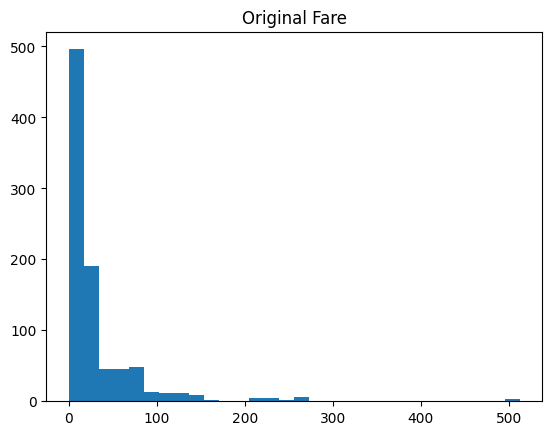

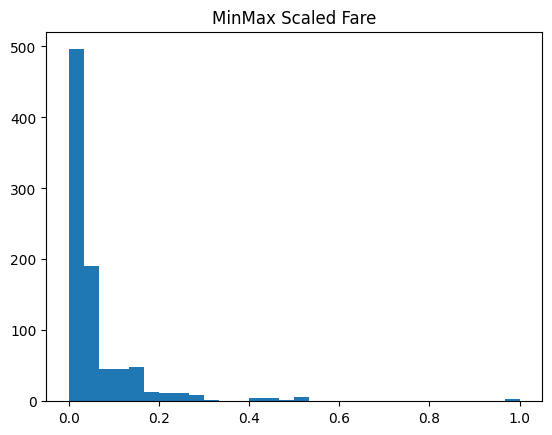

In [48]:
plt.figure()

plt.hist(df['fare'].dropna(), bins=30)
plt.title('Original Fare')
plt.show()

plt.hist(df['fare_minmax'].dropna(), bins=30)
plt.title('MinMax Scaled Fare')
plt.show()

## Robust Scalar


In [47]:
scaler = RobustScaler()

df[['age_robust', 'fare_robust']] = scaler.fit_transform(df[['age', 'fare']])

df[['age_robust', 'fare_robust']].head()

,age_robust,fare_robust
0,-0.335664,-0.312011
1,0.559441,2.461242
2,-0.111888,-0.282777
3,0.391608,1.673732
4,0.391608,-0.277363


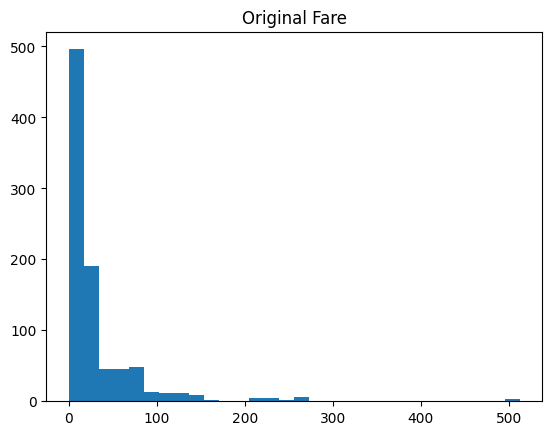

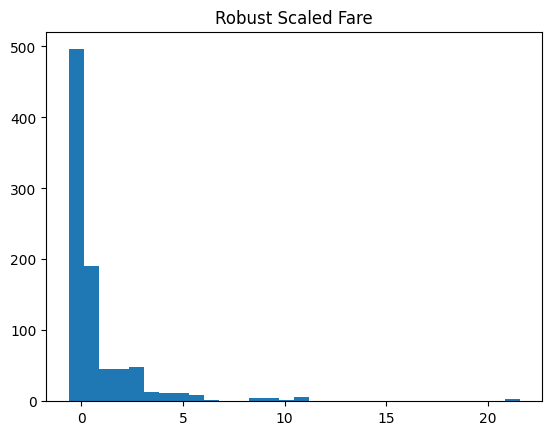

In [49]:
plt.figure()

plt.hist(df['fare'].dropna(), bins=30)
plt.title('Original Fare')
plt.show()

plt.hist(df['fare_robust'].dropna(), bins=30)
plt.title('Robust Scaled Fare')
plt.show()